## Imports

In [1]:
import os
import pandas as pd
import numpy as np

from tqdm import tqdm
import gc

import matplotlib.pyplot as plt

from materials_stock_libs.models.decision_tree import DecisionTreeModels
from materials_stock_libs.utils import (
    generate_future_dates,
    normalizar_codigos,
    filter_segment
    )

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 300)
pd.set_option('display.width', 100)

import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

## Importing environment variables

In [2]:
ROOT_PATH = os.path.join(os.getcwd(), '..')
DATA_PATH = os.path.join(ROOT_PATH, 'data')
OUTPUTS_PATH = os.path.join(ROOT_PATH, 'outputs')
MODEL_PATH = os.path.join(ROOT_PATH, 'trained_models')

DATA_CEN_01 = os.path.join(DATA_PATH, 'DS_CEN_01_EAN')
DATA_PATH_CEN_02 = os.path.join(DATA_PATH, 'DS_CEN_02_EAN')

In [3]:
np.random.seed(42)

## Data Loading

In [4]:
if os.path.exists(os.path.join(DATA_PATH_CEN_02, 'BASE_VENDAS_EXTERNAS_EAN_TODOS.parquet')):
    df_ext_pivot = pd.read_parquet(os.path.join(DATA_PATH_CEN_02, 'BASE_VENDAS_EXTERNAS_EAN_TODOS.parquet'))
    df_ext_pivot = normalizar_codigos(df_ext_pivot, coluna='EAN', como='int', output_col='EAN')
    print(f"Arquivo 'BASE_VENDAS_EXTERNAS_EAN_TODOS.parquet' já processado e carregado.")

else:
    print("Arquivo não encontrado com esse nome")

Arquivo 'BASE_VENDAS_EXTERNAS_EAN_TODOS.parquet' já processado e carregado.


In [5]:
df_ext_pivot.head()

,EAN,PRODUCT_DESC,UF,DISTRIBUIDOR,MEDICAMENTO,ATC1,NEC1,AREA_FARMACIA,DT_EMISSAO,RS_PC,RS_PPP,RS_PR,QUANTIDADE
0,7892950000000,BIO-VAGIN (A5U),CE,OUTROS,MEDICAMENTO,G - SIST GENITUR/HORM/SEX,98 - NOT OTC,PRESCRICAO,2023-06-01,26053.65,20926.35,22542.30,405.0
1,7892950000000,BIO-VAGIN (A5U),CE,OUTROS,MEDICAMENTO,G - SIST GENITUR/HORM/SEX,98 - NOT OTC,PRESCRICAO,2023-07-01,28555.65,23562.75,24768.70,445.0
2,7892950000000,BIO-VAGIN (A5U),CE,OUTROS,MEDICAMENTO,G - SIST GENITUR/HORM/SEX,98 - NOT OTC,PRESCRICAO,2023-08-01,30214.65,24769.89,26215.86,471.0
3,7892950000000,BIO-VAGIN (A5U),CE,OUTROS,MEDICAMENTO,G - SIST GENITUR/HORM/SEX,98 - NOT OTC,PRESCRICAO,2023-09-01,24864.88,20399.16,21651.74,389.0
4,7892950000000,BIO-VAGIN (A5U),CE,OUTROS,MEDICAMENTO,G - SIST GENITUR/HORM/SEX,98 - NOT OTC,PRESCRICAO,2023-10-01,25892.75,21189.74,22430.98,403.0


In [6]:
df_ext_pivot[['PRODUCT_DESC','EAN']].value_counts().reset_index(name="COUNT")

,PRODUCT_DESC,EAN,COUNT
0,CATARINENSE NUTRICAO (C&S),7896020000000,1944
1,KATIGUA (NL7),7898710000000,1920
2,AVVIO PHARMA (AVV),7898720000000,1608
3,CONDOR (C2O),7891060000000,1440
4,OAZ (EUF),7891320000000,1440
...,...,...,...
16871,PICOLINATO CROMO (VMF),7898950000000,24
16872,PICOLINATO CROMO (U.N),7908050000000,24
16873,PICOLINATO CROMO (BKU),7898710000000,24
16874,PICKY EATER KIDS (T.R),609963000000,24


## Treinamento modelos

### Pré-processamento dos dados

In [7]:
# Considerando por produto
df_ext_pivot_prod_01 = df_ext_pivot[df_ext_pivot['PRODUCT_DESC'] == list(df_ext_pivot['PRODUCT_DESC'].unique())[0]]

# Define colunas categóricas e numéricas
categorical_cols = ['UF', 'DISTRIBUIDOR', 'MEDICAMENTO', 'ATC1', 'NEC1', 'AREA_FARMACIA']
numeric_cols = []

df_segment = df_ext_pivot_prod_01[df_ext_pivot_prod_01["UF"] == "CE"]

trainer = DecisionTreeModels(
    df=df_segment,
    date_col='DT_EMISSAO',
    target_col='QUANTIDADE',
    filter_col='UF',
    segment_value='CE',
    seed=42
)

In [8]:
df_segment.shape

(24, 13)

### Modelo 01 - Linear Regression

In [9]:
model_type = 'linear'   # altere para 'rf' ou 'linear' se quiser testar outros

# Treina um modelo RF
resultado = trainer.train_model(
    df_segment=df_segment,
    date_col='DT_EMISSAO',
    model_type = model_type,  # ou 'rf', 'linear'
    categorical_cols= categorical_cols,
    numeric_cols= numeric_cols,
    test_size=0.2,             # 3 períodos de teste
    n_splits=5,              # número de divisões
    walk_forward=True,       # ativa walk-forward
    # num_leaves=31,
    # learning_rate=0.05,
    # n_estimators=300
)

📈 Walk-forward: 7 splits gerados
📈 Split 1: RMSE = 20.5361
📈 Split 2: RMSE = 20.5361
📈 Split 3: RMSE = 20.5361
📈 Split 4: RMSE = 20.5361
📈 Split 5: RMSE = 20.5361
📈 Split 6: RMSE = 20.5361
📈 Split 7: RMSE = 20.5361

✅ Treinamento finalizado!
🏆 Melhor modelo: LINEAR | RMSE: 20.5361


In [10]:
future_dates = pd.date_range(df_segment['DT_EMISSAO'].max() + pd.offsets.MonthBegin(1), periods=3, freq='MS')

#categorical_dict = {'UF': 'CE'}

forecast = trainer.predict_future(
    model_key=model_type, 
    future_dates=future_dates,
    #categorical_defaults=categorical_dict
)

print(forecast)

          ds        yhat
0 2025-06-01  272.318284
1 2025-07-01  265.991188
2 2025-08-01  259.453189


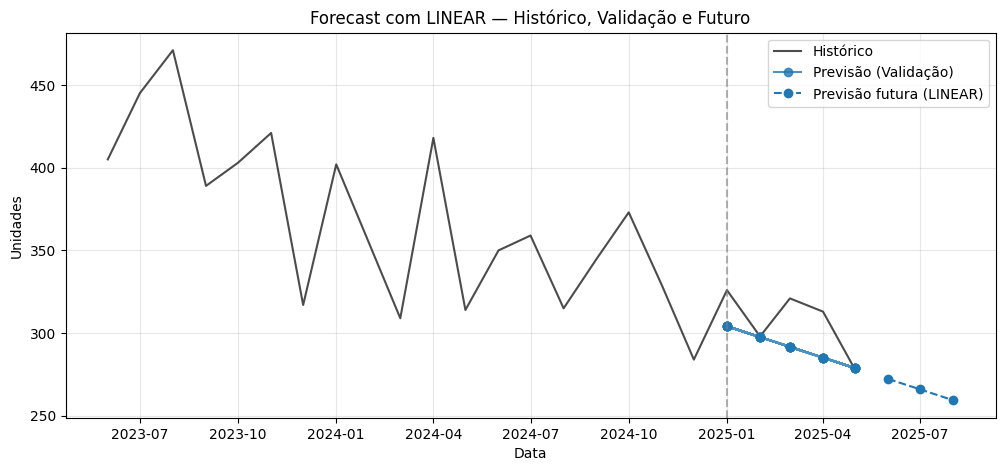

In [11]:
trainer.plot_dt_model(df_segment, model_type, forecast)

In [12]:
best_params = trainer.optimize_model(
    df_segment=df_segment,      # seu dataframe segmentado
    date_col='DT_EMISSAO',
    target_col='QUANTIDADE',         # coluna alvo
    model_type=model_type,
    categorical_cols=categorical_cols,
    numeric_cols=numeric_cols,
    n_trials=10,                # menor número para teste rápido
    n_splits=3                  # 3 folds de validação temporal
)

print("📌 Hiperparâmetros Otimizados:")
print(best_params)

[I 2025-11-02 23:33:11,063] A new study created in memory with name: no-name-2ec9b5d8-d858-4ba2-a111-dcde753f2564
[I 2025-11-02 23:33:11,096] Trial 0 finished with value: 44.11291627710276 and parameters: {'fit_intercept': True}. Best is trial 0 with value: 44.11291627710276.
[I 2025-11-02 23:33:11,111] Trial 1 finished with value: 67.10504761777676 and parameters: {'fit_intercept': False}. Best is trial 0 with value: 44.11291627710276.
[I 2025-11-02 23:33:11,126] Trial 2 finished with value: 44.11291627710276 and parameters: {'fit_intercept': True}. Best is trial 0 with value: 44.11291627710276.
[I 2025-11-02 23:33:11,141] Trial 3 finished with value: 67.10504761777676 and parameters: {'fit_intercept': False}. Best is trial 0 with value: 44.11291627710276.
[I 2025-11-02 23:33:11,159] Trial 4 finished with value: 67.10504761777676 and parameters: {'fit_intercept': False}. Best is trial 0 with value: 44.11291627710276.
[I 2025-11-02 23:33:11,178] Trial 5 finished with value: 44.11291627

✅ Melhor RMSE: 44.1129
🔧 Melhores Hiperparâmetros:
  - fit_intercept: True
📌 Hiperparâmetros Otimizados:
{'fit_intercept': True}


In [13]:
print("\nMelhores hiperparâmetros encontrados:")
print(best_params)


Melhores hiperparâmetros encontrados:
{'fit_intercept': True}


📈 Walk-forward: 7 splits gerados
📈 Split 1: RMSE = 20.5361
📈 Split 2: RMSE = 20.5361
📈 Split 3: RMSE = 20.5361
📈 Split 4: RMSE = 20.5361
📈 Split 5: RMSE = 20.5361
📈 Split 6: RMSE = 20.5361
📈 Split 7: RMSE = 20.5361

✅ Treinamento finalizado!
🏆 Melhor modelo: LINEAR | RMSE: 20.5361
          ds        yhat
0 2025-06-01  272.318284
1 2025-07-01  265.991188
2 2025-08-01  259.453189


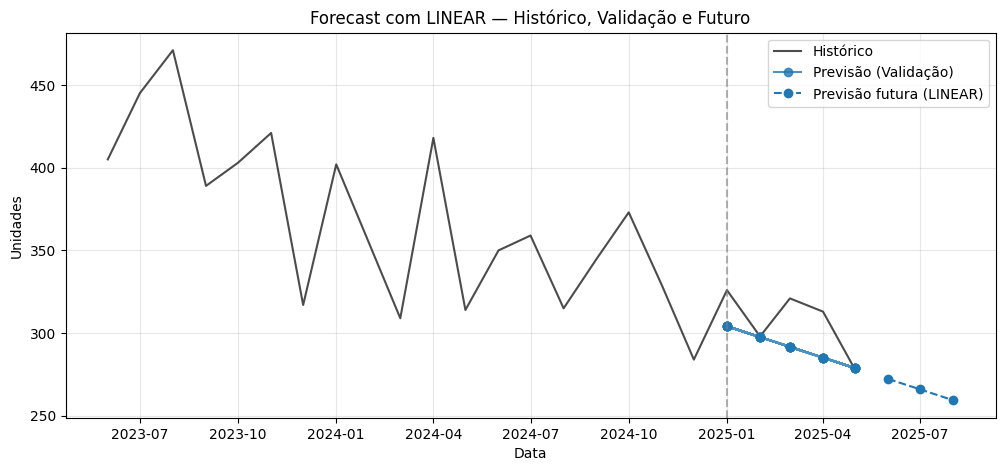

In [15]:
# Otimizando hiperparâmetros, retreinando, realizando a inferência e trazendo o gráfico com o modelo otimizado
resultado = trainer.train_model(
    df_segment=df_segment,
    date_col='DT_EMISSAO',
    model_type = model_type,  # ou 'rf', 'linear'
    categorical_cols= categorical_cols,
    numeric_cols= numeric_cols,
    test_size=0.2,             # 3 períodos de teste
    n_splits=5,              # número de divisões
    walk_forward=True,       # ativa walk-forward
    **best_params
)

future_dates = pd.date_range(df_segment['DT_EMISSAO'].max() + pd.offsets.MonthBegin(1), periods=3, freq='MS')
forecast = trainer.predict_future(model_key=model_type, future_dates=future_dates)

print(forecast)

df_ext_pivot_filtered = filter_segment(df_segment, 'UF', 'CE')

trainer.plot_dt_model(df_ext_pivot_filtered, model_type, forecast)

In [21]:
# Salvar o modelo treinado
import joblib
os.makedirs(MODEL_PATH, exist_ok=True)
joblib.dump(trainer.models['linear'], os.path.join(MODEL_PATH, 'LINREG_CE_prod01_model.pkl'))

# Carregar novamente
loaded_model = joblib.load(os.path.join(MODEL_PATH, 'LINREG_CE_prod01_model.pkl'))

### Modelo 02 - RandomForest Regressor

In [17]:
model_type = 'rf'   # altere para 'rf' ou 'linear' se quiser testar outros

# Treina um modelo RF
resultado = trainer.train_model(
    df_segment=df_segment,
    date_col='DT_EMISSAO',
    model_type = model_type,  # ou 'rf', 'linear'
    categorical_cols= categorical_cols,
    numeric_cols= numeric_cols,
    test_size=0.2,             # 3 períodos de teste
    n_splits=3,              # número de divisões
    walk_forward=True,       # ativa walk-forward
    # num_leaves=31,
    # learning_rate=0.05,
    # n_estimators=300
)

📈 Walk-forward: 4 splits gerados
📈 Split 1: RMSE = 18.2661
📈 Split 2: RMSE = 18.2661
📈 Split 3: RMSE = 18.2661
📈 Split 4: RMSE = 18.2661

✅ Treinamento finalizado!
🏆 Melhor modelo: RF | RMSE: 18.2661


In [18]:
future_dates = pd.date_range(df_segment['DT_EMISSAO'].max() + pd.offsets.MonthBegin(1), periods=3, freq='MS')

#categorical_dict = {'UF': 'CE'}

forecast = trainer.predict_future(
    model_key=model_type, 
    future_dates=future_dates,
    #categorical_defaults=categorical_dict
)

print(forecast)

          ds    yhat
0 2025-06-01  301.66
1 2025-07-01  301.66
2 2025-08-01  301.66


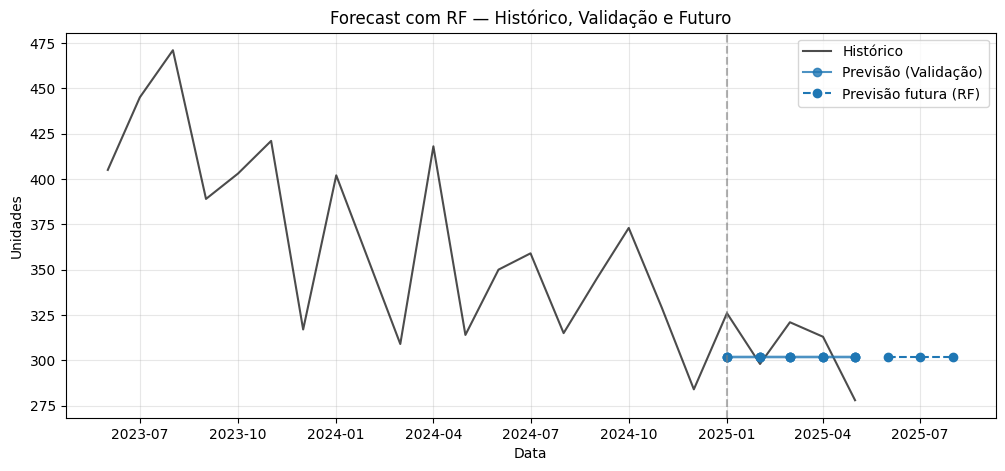

In [19]:
trainer.plot_dt_model(df_segment, model_type, forecast)

In [20]:
best_params = trainer.optimize_model(
    df_segment=df_segment,      # seu dataframe segmentado
    date_col='DT_EMISSAO',
    target_col='QUANTIDADE',         # coluna alvo
    model_type=model_type,
    categorical_cols=categorical_cols,
    numeric_cols=numeric_cols,
    n_trials=10,                # menor número para teste rápido
    n_splits=3                  # 3 folds de validação temporal
)

print("📌 Hiperparâmetros Otimizados:")
print(best_params)

[I 2025-11-02 23:53:28,557] A new study created in memory with name: no-name-26dd8410-fe20-4eb0-bbc1-8d4626b84b2e


[I 2025-11-02 23:53:29,120] Trial 0 finished with value: 48.084153917411555 and parameters: {'n_estimators': 158, 'max_depth': 26, 'min_samples_split': 9, 'min_samples_leaf': 5, 'max_features': 'log2', 'bootstrap': False}. Best is trial 0 with value: 48.084153917411555.
[I 2025-11-02 23:53:30,161] Trial 1 finished with value: 57.433873340141766 and parameters: {'n_estimators': 273, 'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 0 with value: 48.084153917411555.
[I 2025-11-02 23:53:31,231] Trial 2 finished with value: 56.88740775608026 and parameters: {'n_estimators': 263, 'max_depth': 13, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': True}. Best is trial 0 with value: 48.084153917411555.
[I 2025-11-02 23:53:31,783] Trial 3 finished with value: 65.73958036703355 and parameters: {'n_estimators': 152, 'max_depth': 3, 'min_samples_split': 4, 'min_samples_leaf': 8, 'max_features

✅ Melhor RMSE: 48.0842
🔧 Melhores Hiperparâmetros:
  - n_estimators: 311
  - max_depth: 21
  - min_samples_split: 8
  - min_samples_leaf: 2
  - max_features: None
  - bootstrap: False
📌 Hiperparâmetros Otimizados:
{'n_estimators': 311, 'max_depth': 21, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': False}


In [21]:
print("\nMelhores hiperparâmetros encontrados:")
print(best_params)


Melhores hiperparâmetros encontrados:
{'n_estimators': 311, 'max_depth': 21, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': False}


📈 Walk-forward: 7 splits gerados
📈 Split 1: RMSE = 17.4198
📈 Split 2: RMSE = 17.4198
📈 Split 3: RMSE = 17.4198
📈 Split 4: RMSE = 17.4198
📈 Split 5: RMSE = 17.4198
📈 Split 6: RMSE = 17.4198
📈 Split 7: RMSE = 17.4198

✅ Treinamento finalizado!
🏆 Melhor modelo: RF | RMSE: 17.4198
          ds   yhat
0 2025-06-01  306.5
1 2025-07-01  306.5
2 2025-08-01  306.5


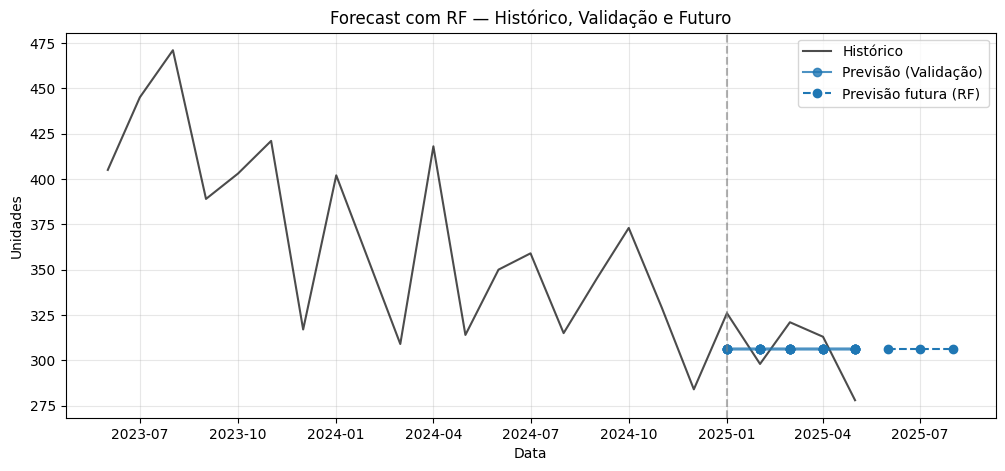

In [24]:
# Otimizando hiperparâmetros, retreinando, realizando a inferência e trazendo o gráfico com o modelo otimizado
resultado = trainer.train_model(
    df_segment=df_segment,
    date_col='DT_EMISSAO',
    model_type = model_type,  # ou 'rf', 'linear'
    categorical_cols= categorical_cols,
    numeric_cols= numeric_cols,
    test_size=0.2,             # 3 períodos de teste
    n_splits=5,              # número de divisões
    walk_forward=True,       # ativa walk-forward
    **best_params
)

future_dates = pd.date_range(df_segment['DT_EMISSAO'].max() + pd.offsets.MonthBegin(1), periods=3, freq='MS')
forecast = trainer.predict_future(model_key=model_type, future_dates=future_dates)

print(forecast)

df_ext_pivot_filtered = filter_segment(df_segment, 'UF', 'CE')
trainer.plot_dt_model(df_ext_pivot_filtered, model_type, forecast)

In [25]:
# Salvar o modelo treinado
import joblib
os.makedirs(MODEL_PATH, exist_ok=True)
joblib.dump(trainer.models['rf'], os.path.join(MODEL_PATH,'RF_CE_prod01_model.pkl'))

# Carregar novamente
loaded_model = joblib.load(os.path.join(MODEL_PATH,'RF_CE_prod01_model.pkl'))

### Modelo 03 - LightGBM Regressor

In [26]:
model_type = 'lgbm'   # altere para 'rf' ou 'linear' se quiser testar outros

# Treina um modelo RF
resultado = trainer.train_model(
    df_segment=df_segment,
    date_col='DT_EMISSAO',
    model_type = model_type,  # ou 'rf', 'linear'
    categorical_cols= categorical_cols,
    numeric_cols= numeric_cols,
    test_size=0.2,             # 3 períodos de teste
    n_splits=5,              # número de divisões
    walk_forward=True       # ativa walk-forward
)

📈 Walk-forward: 7 splits gerados
[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 19, number of used features: 0
[LightGBM] [Info] Start training from score 368.578947
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there ar

In [27]:
future_dates = pd.date_range(df_segment['DT_EMISSAO'].max() + pd.offsets.MonthBegin(1), periods=3, freq='MS')

#categorical_dict = {'UF': 'CE'}

forecast = trainer.predict_future(
    model_key=model_type, 
    future_dates=future_dates,
    #categorical_defaults=categorical_dict
)

print(forecast)

          ds        yhat
0 2025-06-01  368.578947
1 2025-07-01  368.578947
2 2025-08-01  368.578947


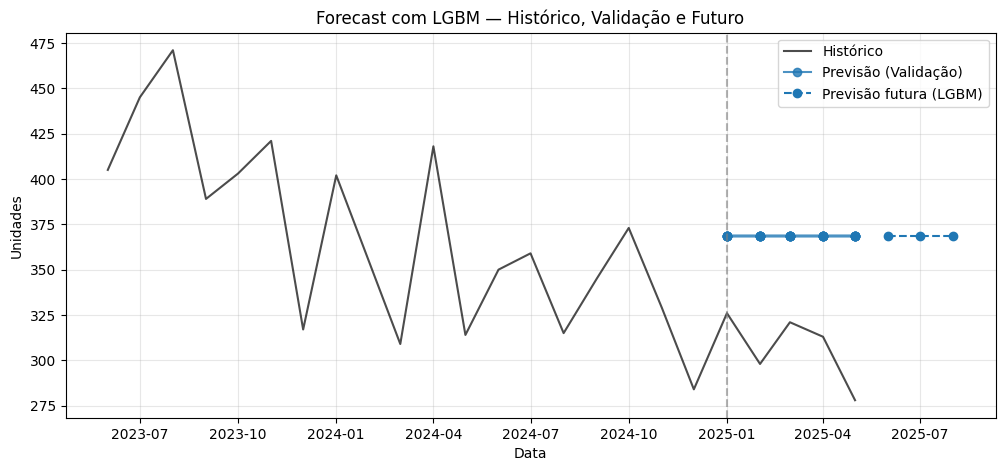

In [28]:
df_ext_pivot_filtered = filter_segment(df_ext_pivot_prod_01, 'UF', 'CE')
trainer.plot_dt_model(df_ext_pivot_filtered, model_type, forecast)

In [29]:
best_params = trainer.optimize_model(
    df_segment=df_segment,      # seu dataframe segmentado
    date_col='DT_EMISSAO',
    target_col='QUANTIDADE',         # coluna alvo
    model_type=model_type,
    categorical_cols=categorical_cols,
    numeric_cols=numeric_cols,
    n_trials=10,                # menor número para teste rápido
    n_splits=3                  # 3 folds de validação temporal
)

print("📌 Hiperparâmetros Otimizados:")
print(best_params)

[I 2025-11-02 23:56:21,374] A new study created in memory with name: no-name-117a84da-b425-45a4-ae76-6d47043d2192
[I 2025-11-02 23:56:21,428] Trial 0 finished with value: 66.97508717389923 and parameters: {'num_leaves': 61, 'max_depth': 9, 'learning_rate': 0.2154777718898806, 'n_estimators': 271, 'min_child_samples': 30, 'subsample': 0.6097348195732113, 'colsample_bytree': 0.6625042810797388, 'reg_alpha': 0.34412992359658745, 'reg_lambda': 0.8777467120709621}. Best is trial 0 with value: 66.97508717389923.
[I 2025-11-02 23:56:21,457] Trial 1 finished with value: 66.97508717389923 and parameters: {'num_leaves': 21, 'max_depth': 3, 'learning_rate': 0.011236297680085966, 'n_estimators': 182, 'min_child_samples': 22, 'subsample': 0.9702610491646759, 'colsample_bytree': 0.8420508682013961, 'reg_alpha': 0.3096629784790228, 'reg_lambda': 0.020929181139955455}. Best is trial 0 with value: 66.97508717389923.
[I 2025-11-02 23:56:21,490] Trial 2 finished with value: 66.97508717389923 and paramete

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 6, number of used features: 0
[LightGBM] [Info] Start training from score 422.333333
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the spl

[I 2025-11-02 23:56:21,637] Trial 6 finished with value: 66.97508717389923 and parameters: {'num_leaves': 77, 'max_depth': 7, 'learning_rate': 0.28501931207051734, 'n_estimators': 368, 'min_child_samples': 19, 'subsample': 0.6035999105871008, 'colsample_bytree': 0.8455767346907934, 'reg_alpha': 0.4664851642778577, 'reg_lambda': 0.9590288157319556}. Best is trial 0 with value: 66.97508717389923.
[I 2025-11-02 23:56:21,679] Trial 7 finished with value: 66.97508717389923 and parameters: {'num_leaves': 37, 'max_depth': 10, 'learning_rate': 0.051413223561301076, 'n_estimators': 355, 'min_child_samples': 27, 'subsample': 0.8223673533956093, 'colsample_bytree': 0.6657565390707076, 'reg_alpha': 0.2939049986970279, 'reg_lambda': 0.3105850818863075}. Best is trial 0 with value: 66.97508717389923.
[I 2025-11-02 23:56:21,723] Trial 8 finished with value: 66.97508717389923 and parameters: {'num_leaves': 78, 'max_depth': 12, 'learning_rate': 0.012697775955152214, 'n_estimators': 212, 'min_child_samp

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 6, number of used features: 0
[LightGBM] [Info] Start training from score 422.333333
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the spl

In [30]:
print("\nMelhores hiperparâmetros encontrados:")
print(best_params)


Melhores hiperparâmetros encontrados:
{'num_leaves': 61, 'max_depth': 9, 'learning_rate': 0.2154777718898806, 'n_estimators': 271, 'min_child_samples': 30, 'subsample': 0.6097348195732113, 'colsample_bytree': 0.6625042810797388, 'reg_alpha': 0.34412992359658745, 'reg_lambda': 0.8777467120709621}


📈 Walk-forward: 7 splits gerados
[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 19, number of used features: 0
[LightGBM] [Info] Start training from score 368.578947
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there ar

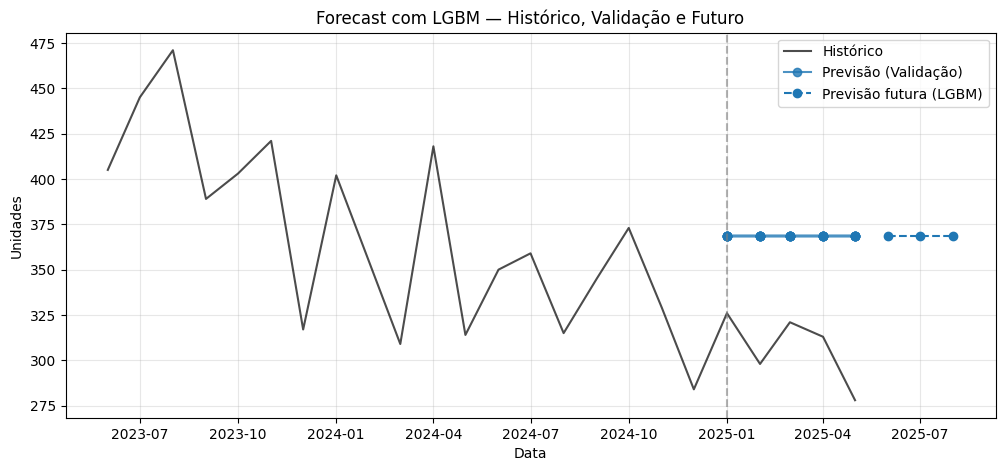

In [32]:
# Otimizando hiperparâmetros, retreinando, realizando a inferência e trazendo o gráfico com o modelo otimizado
resultado = trainer.train_model(
    df_segment=df_segment,
    date_col='DT_EMISSAO',
    model_type = model_type,  # ou 'rf', 'linear'
    categorical_cols= categorical_cols,
    numeric_cols= numeric_cols,
    test_size=0.2,             # 3 períodos de teste
    n_splits=5,              # número de divisões
    walk_forward=True,       # ativa walk-forward
    **best_params
)

future_dates = pd.date_range(df_segment['DT_EMISSAO'].max() + pd.offsets.MonthBegin(1), periods=3, freq='MS')
forecast = trainer.predict_future(model_key=model_type, future_dates=future_dates)

print(forecast)

df_ext_pivot_filtered = filter_segment(df_segment, 'UF', 'CE')
trainer.plot_dt_model(df_ext_pivot_filtered, model_type, forecast)

In [33]:
# Salvar o modelo treinado
import joblib
os.makedirs(MODEL_PATH, exist_ok=True)
joblib.dump(trainer.models['lgbm'], os.path.join(MODEL_PATH,'LGBM_CE_prod01_model.pkl'))

# Carregar novamente
loaded_model = joblib.load(os.path.join(MODEL_PATH,'LGBM_CE_prod01_model.pkl'))